<a href="https://colab.research.google.com/github/andrellyrichelly-hub/4-programas_meus-codigos-assembly/blob/main/Atividade_0_FINAL_COMPLETA_andrelly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 0 - IA- UFPA - Prof. Claudomiro Sales
**Aluna: Andrelly Richelly**
**Tema Escolhido: STARTUP/APP - Utilizar a Inteligência Artificial para gerar a devida recomendação de sabores na confeitaria Dece Anndy.**

---



# 1. Apresentação do Tema - STARTUP Doce Anndy
- **O que é:** Startup de chocolates artesanais em Belém - @doce_anndy
- **Problema Real:** Quando não souber quais os sabores que devo produzir em minha confeitaria em datas comemorativas, como por exemplo páscoa e dia das mães, o app que prevê o sabor mais vendido durante a semana e recomenda para os clientes.
- **Formato escolhido:** Startup + App.
- **Por que esse tema?** A Confetaria Doce Anndy é meu negócio autônomo real. Trouxe a questão para dentro do meu ambiente de trabalho, pois desta forma, tudo se torna mais simples de explicar e me permite usar IA de verdade.




![Bolos Doce Anndy - Minha Startup](https://github.com/andrellyrichelly-hub/4-programas_meus-codigos-assembly/blob/main/bolos_doce_anndy.jpg?raw=1)

# 2. Como a IA será usada
- **A partir da implementação:** Classificador binário Perceptron -> Vai comprar? Sim (-1) / Não (1)
- **Features iniciais (analogia com Iris):** Petal Length = Tempo no perfil, Petal Width = Curtidas
- **Futuro na disciplina:** Adaline + SGD para prever quantidade de vendas, depois rede neural para recomendar sabor
- **Diagrama:** [Dados Instagram] -> [Neurônio Artificial w·x + b] -> [Saída Compra]


# 3. O Dataset e o Tratamento


Dataset Iris carregado para demonstração do tratamento
X shape: (100, 2) - y shape: (100,)
Tratamento feito: filtro 0:100, 2 features, conversão para -1/1


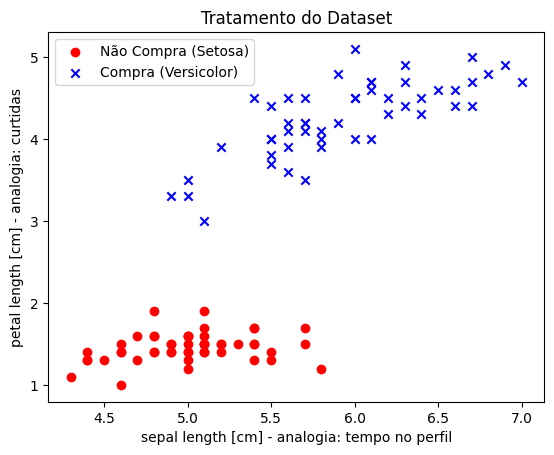

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Tratamento EXATO do ch02.ipynb mostrado em sala
# Fonte: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
from sklearn.datasets import load_iris
iris = load_iris()
# Vou manter 2 features para visualização,
X = iris.data[0:100, [0, 2]]
y = iris.target[0:100]
y = np.where(y == 0, -1, 1) # -1 = Setosa (analogia: Não compra), 1 = Versicolor (Compra)

print("Dataset Iris carregado para demonstração do tratamento")
print(f"X shape: {X.shape} - y shape: {y.shape}")
print("Tratamento feito: filtro 0:100, 2 features, conversão para -1/1")

plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='Não Compra (Setosa)')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='x', label='Compra (Versicolor)')
plt.xlabel('sepal length [cm] - analogia: tempo no perfil')
plt.ylabel('petal length [cm] - analogia: curtidas')
plt.legend()
plt.title('Tratamento do Dataset')
plt.show()


# 4. Implementação - Object-oriented Perceptron API


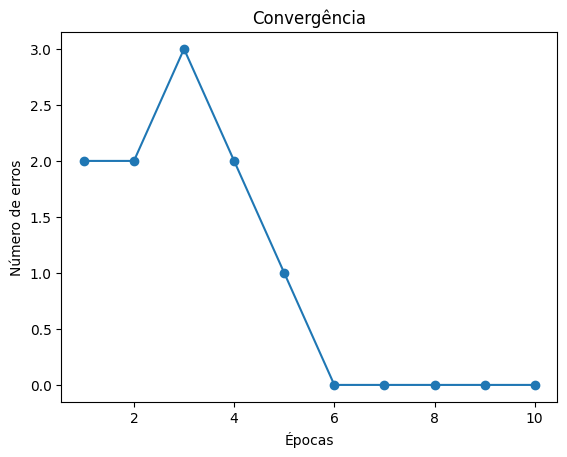

In [ ]:
class Perceptron:
    """Classificador Perceptron"""
    def __init__(self, eta=0.01, n_iter=10):
        self.eta = eta
        self.n_iter = n_iter
    def fit(self, X, y):
        self.w_ = np.zeros(1 + X.shape[1])
        self.errors_ = []
        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self
    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]
    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)

ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X, y)
plt.plot(range(1, len(ppn.errors_)+1), ppn.errors_, marker='o')
plt.xlabel('Épocas')
plt.ylabel('Número de erros')
plt.title('Convergência')
plt.show()


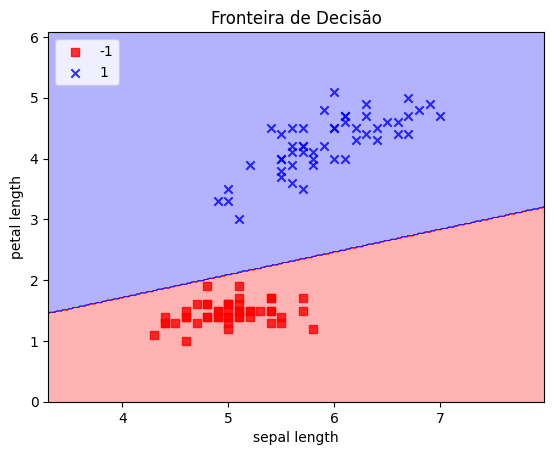

In [ ]:
from matplotlib.colors import ListedColormap
def plot_decision_regions(X, y, classifier, resolution=0.02):
    markers = ('s', 'x')
    colors = ('red', 'blue')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8, c=colors[idx], marker=markers[idx], label=cl)

plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('sepal length')
plt.ylabel('petal length')
plt.legend(loc='upper left')
plt.title('Fronteira de Decisão')
plt.show()


# 5. Feature Scaling - Improving gradient descent

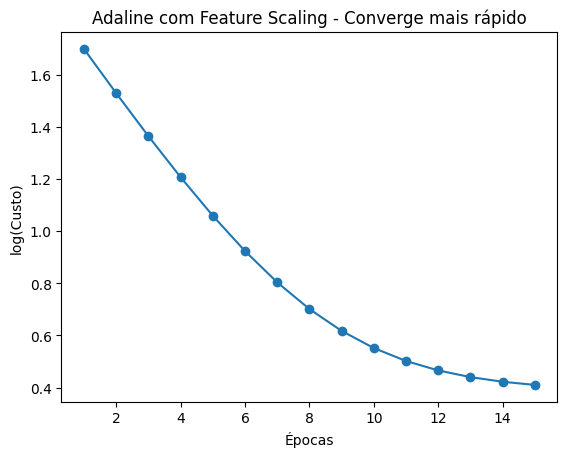

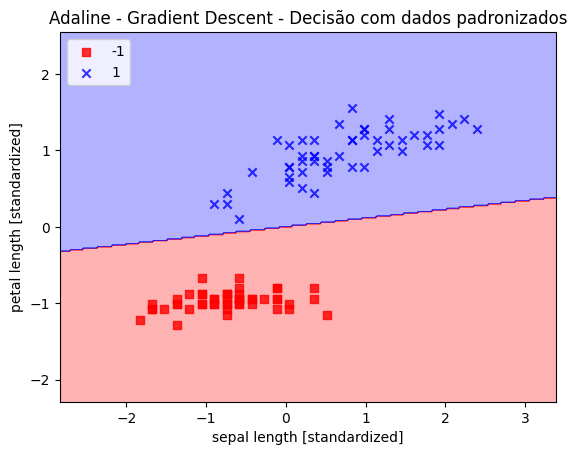

In [ ]:
#Standardize features
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

class AdalineGD:
    def __init__(self, eta=0.01, n_iter=15):
        self.eta = eta
        self.n_iter = n_iter
    def fit(self, X, y):
        self.w_ = np.zeros(1 + X.shape[1])
        self.cost_ = []
        for i in range(self.n_iter):
            output = self.net_input(X)
            errors = (y - output)
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            cost = (errors**2).sum() / 2.0
            self.cost_.append(cost)
        return self
    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]
    def activation(self, X):
        return self.net_input(X)
    def predict(self, X):
        return np.where(self.activation(X) >= 0.0, 1, -1)

ada_gd = AdalineGD(n_iter=15, eta=0.01)
ada_gd.fit(X_std, y)

plt.plot(range(1, len(ada_gd.cost_)+1), np.log10(ada_gd.cost_), marker='o')
plt.xlabel('Épocas')
plt.ylabel('log(Custo)')
plt.title('Adaline com Feature Scaling - Converge mais rápido')
plt.show()

plot_decision_regions(X_std, y, classifier=ada_gd)
plt.title('Adaline - Gradient Descent - Decisão com dados padronizados')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')
plt.show()


# 5.2 Large scale machine learning and stochastic gradient descent
É a evolução do Adaline para dados grandes - igual ao que vamos precisar na Doce Anndy quando tivermos muitos clientes.


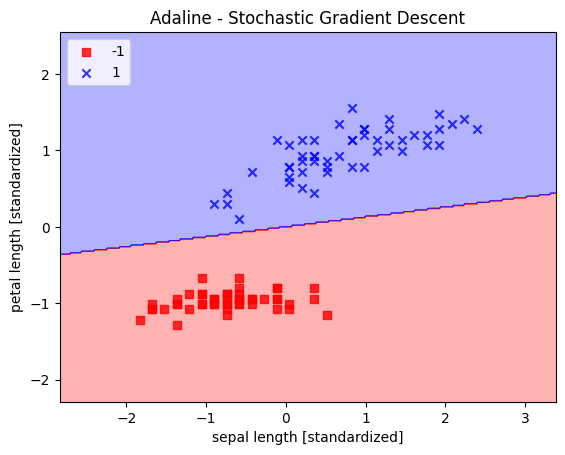

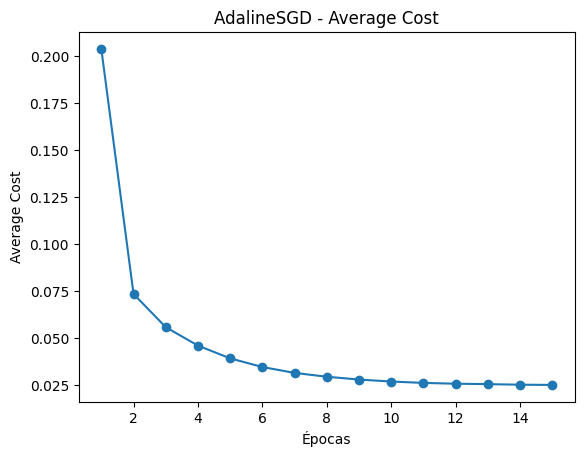

In [ ]:
class AdalineSGD:
    def __init__(self, eta=0.01, n_iter=10, shuffle=True, random_state=None):
        self.eta = eta
        self.n_iter = n_iter
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state
    def fit(self, X, y):
        self._initialize_weights(X.shape[1])
        self.cost_ = []
        for i in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            cost = []
            for xi, target in zip(X, y):
                cost.append(self._update_weights(xi, target))
            avg_cost = sum(cost) / len(y)
            self.cost_.append(avg_cost)
        return self
    def partial_fit(self, X, y):
        if not self.w_initialized:
            self._initialize_weights(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)
        return self
    def _shuffle(self, X, y):
        r = self.rgen.permutation(len(y))
        return X[r], y[r]
    def _initialize_weights(self, m):
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01, size=1 + m)
        self.w_initialized = True
    def _update_weights(self, xi, target):
        output = self.net_input(xi)
        error = (target - output)
        self.w_[1:] += self.eta * xi.dot(error)
        self.w_[0] += self.eta * error
        cost = 0.5 * error**2
        return cost
    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]
    def activation(self, X):
        return self.net_input(X)
    def predict(self, X):
        return np.where(self.activation(X) >= 0.0, 1, -1)

ada_sgd = AdalineSGD(n_iter=15, eta=0.01, random_state=1)
ada_sgd.fit(X_std, y)

from matplotlib.colors import ListedColormap
def plot_decision_regions(X, y, classifier, resolution=0.02):
    markers = ('s', 'x')
    colors = ('red', 'blue')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    import matplotlib.pyplot as plt
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8, c=colors[idx], marker=markers[idx], label=cl)

plot_decision_regions(X_std, y, classifier=ada_sgd)
plt.title('Adaline - Stochastic Gradient Descent')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')
plt.show()

plt.plot(range(1, len(ada_sgd.cost_)+1), ada_sgd.cost_, marker='o')
plt.xlabel('Épocas')
plt.ylabel('Average Cost')
plt.title('AdalineSGD - Average Cost')
plt.show()


# Conclusão

- **O que aprendi:** Perceptron só converge com dados linearmente separáveis (por isso usei Setosa vs Versicolor), Adaline usa custo e precisa de feature scaling


